In [14]:
import tonic
from tonic import datasets, transforms
from torch.utils.data import DataLoader

# 데이터셋 다운로드 및 로드
download_dir = './'  # 데이터를 저장할 경로
train_data = datasets.SHD(save_to=download_dir, train=True)
test_data = datasets.SHD(save_to=download_dir, train=False)


Number of training samples: 8156
Number of testing samples: 2264


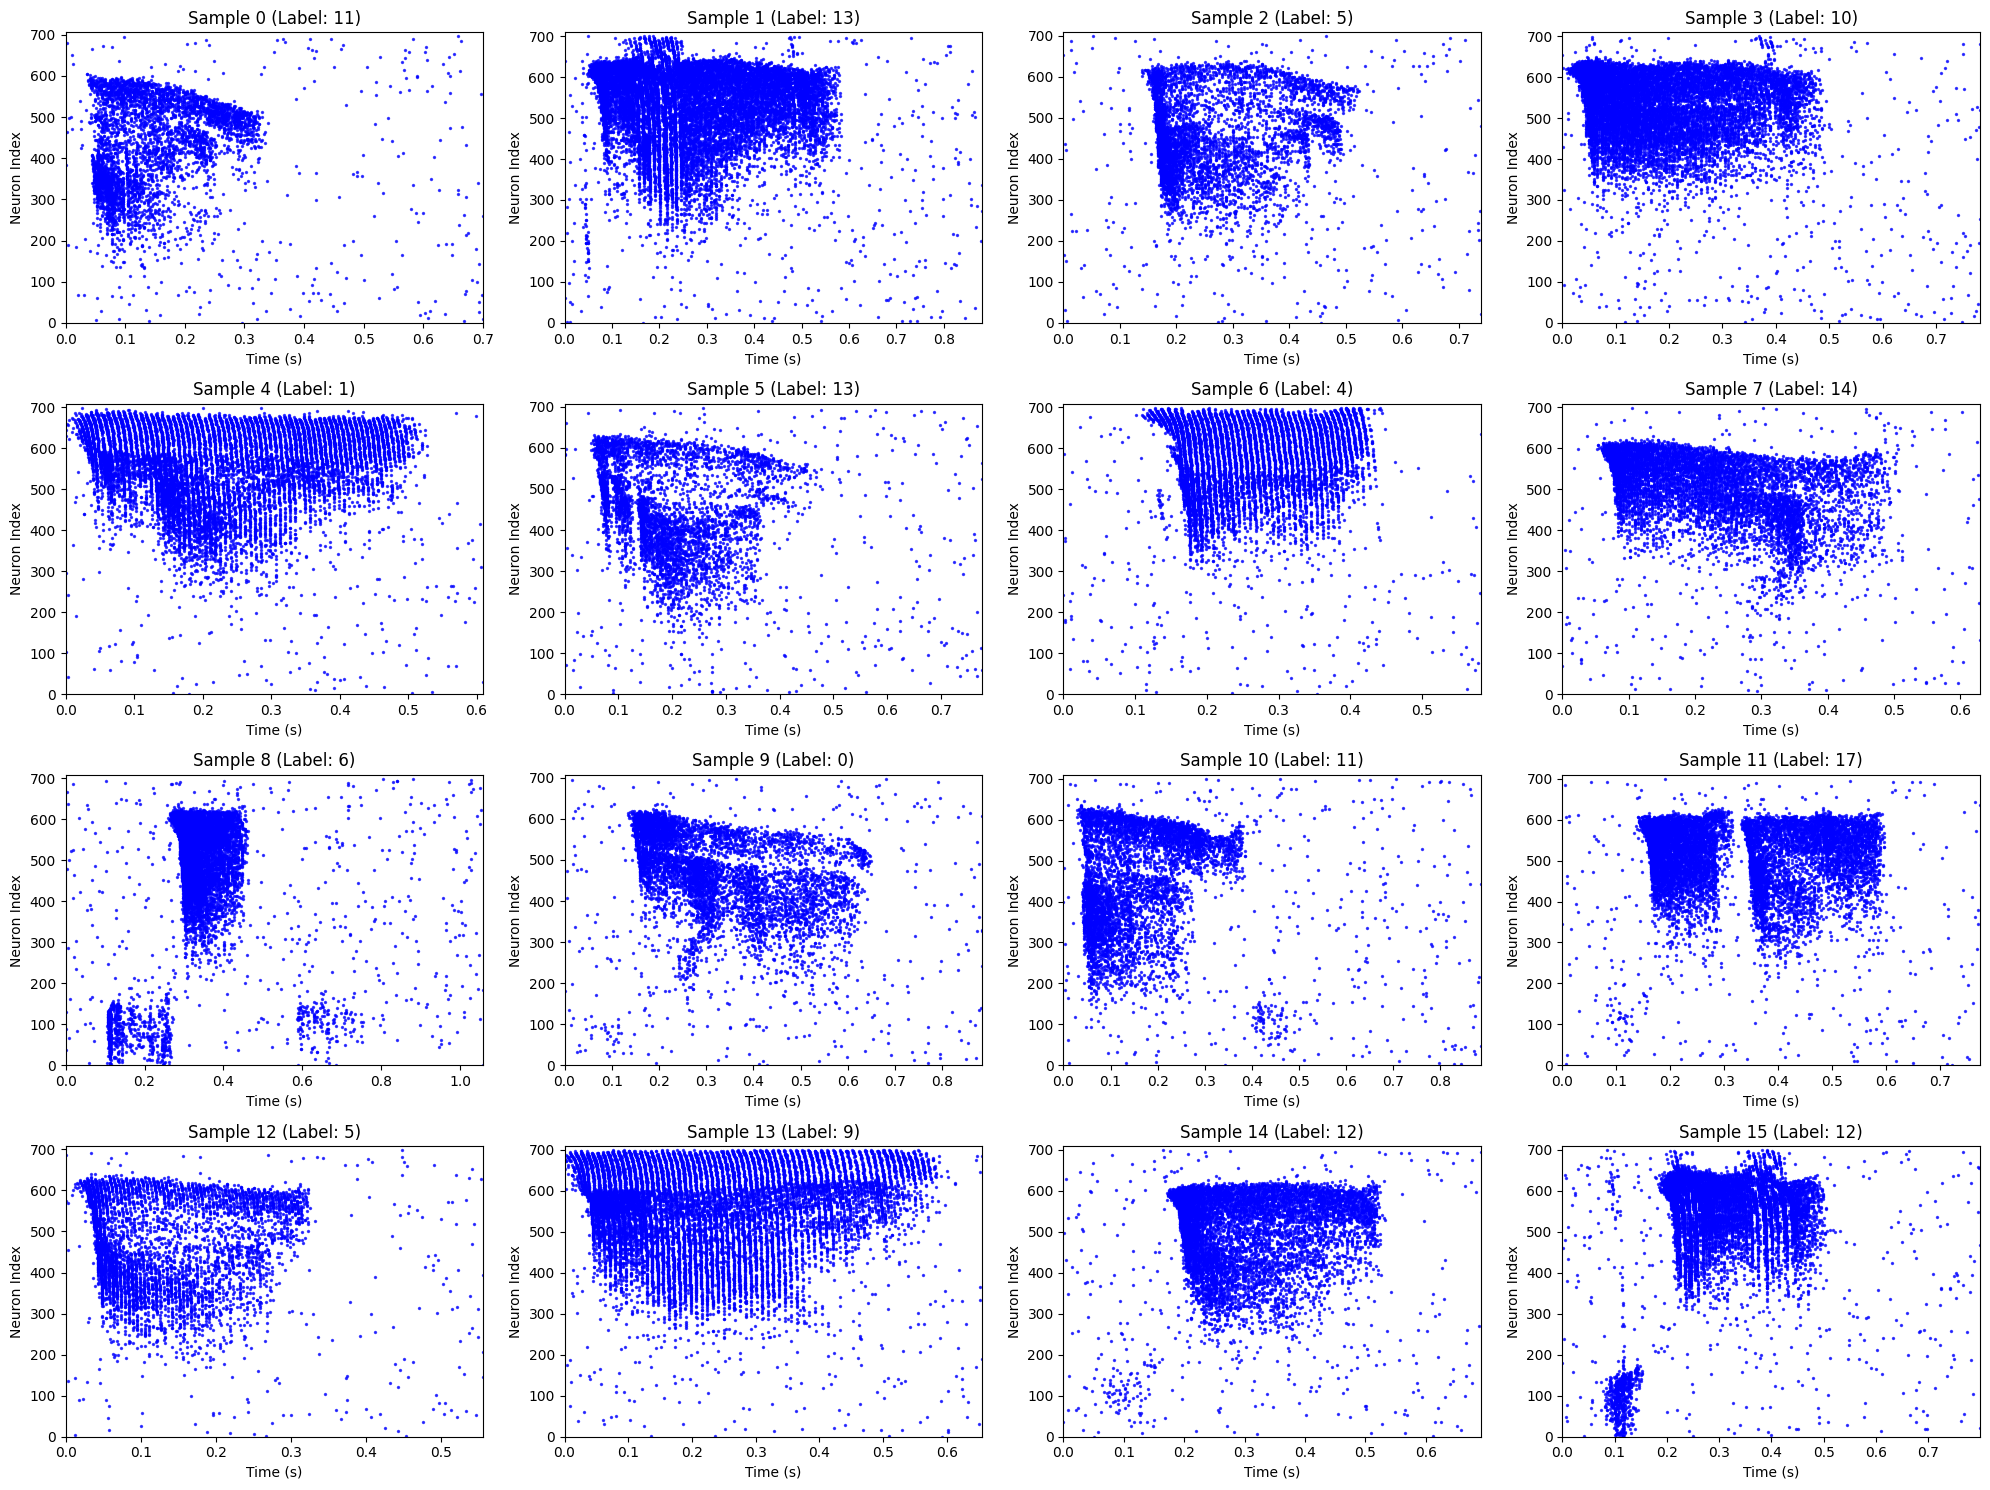

In [15]:
# 데이터 확인
print(f"Number of training samples: {len(train_data)}")
print(f"Number of testing samples: {len(test_data)}")

train_data = datasets.SHD(save_to=download_dir, train=True)

def visualize_shd_samples(data, num_samples=16):
    fig, axes = plt.subplots(4, 4, figsize=(20, 15))
    axes = axes.flatten()

    for idx in range(num_samples):
        events, label = data[idx]

        # 시간과 뉴런 인덱스 추출 (1차원 배열 처리)
        times = np.array([event[0] for event in events])  # time 추출
        neurons = np.array([event[1] for event in events])  # neuron_index 추출

        ax = axes[idx]
        ax.scatter(times / 1e6, neurons, s=2, alpha=0.7, color='blue')  # μs → 초 변환
        ax.set_title(f"Sample {idx} (Label: {label})")
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Neuron Index")
        ax.set_xlim(0, max(times) / 1e6 if len(times) > 0 else 1)
        ax.set_ylim(0, max(neurons) + 10 if len(neurons) > 0 else 10)

    plt.tight_layout()
    plt.show()

# 시각화 실행
visualize_shd_samples(train_data)

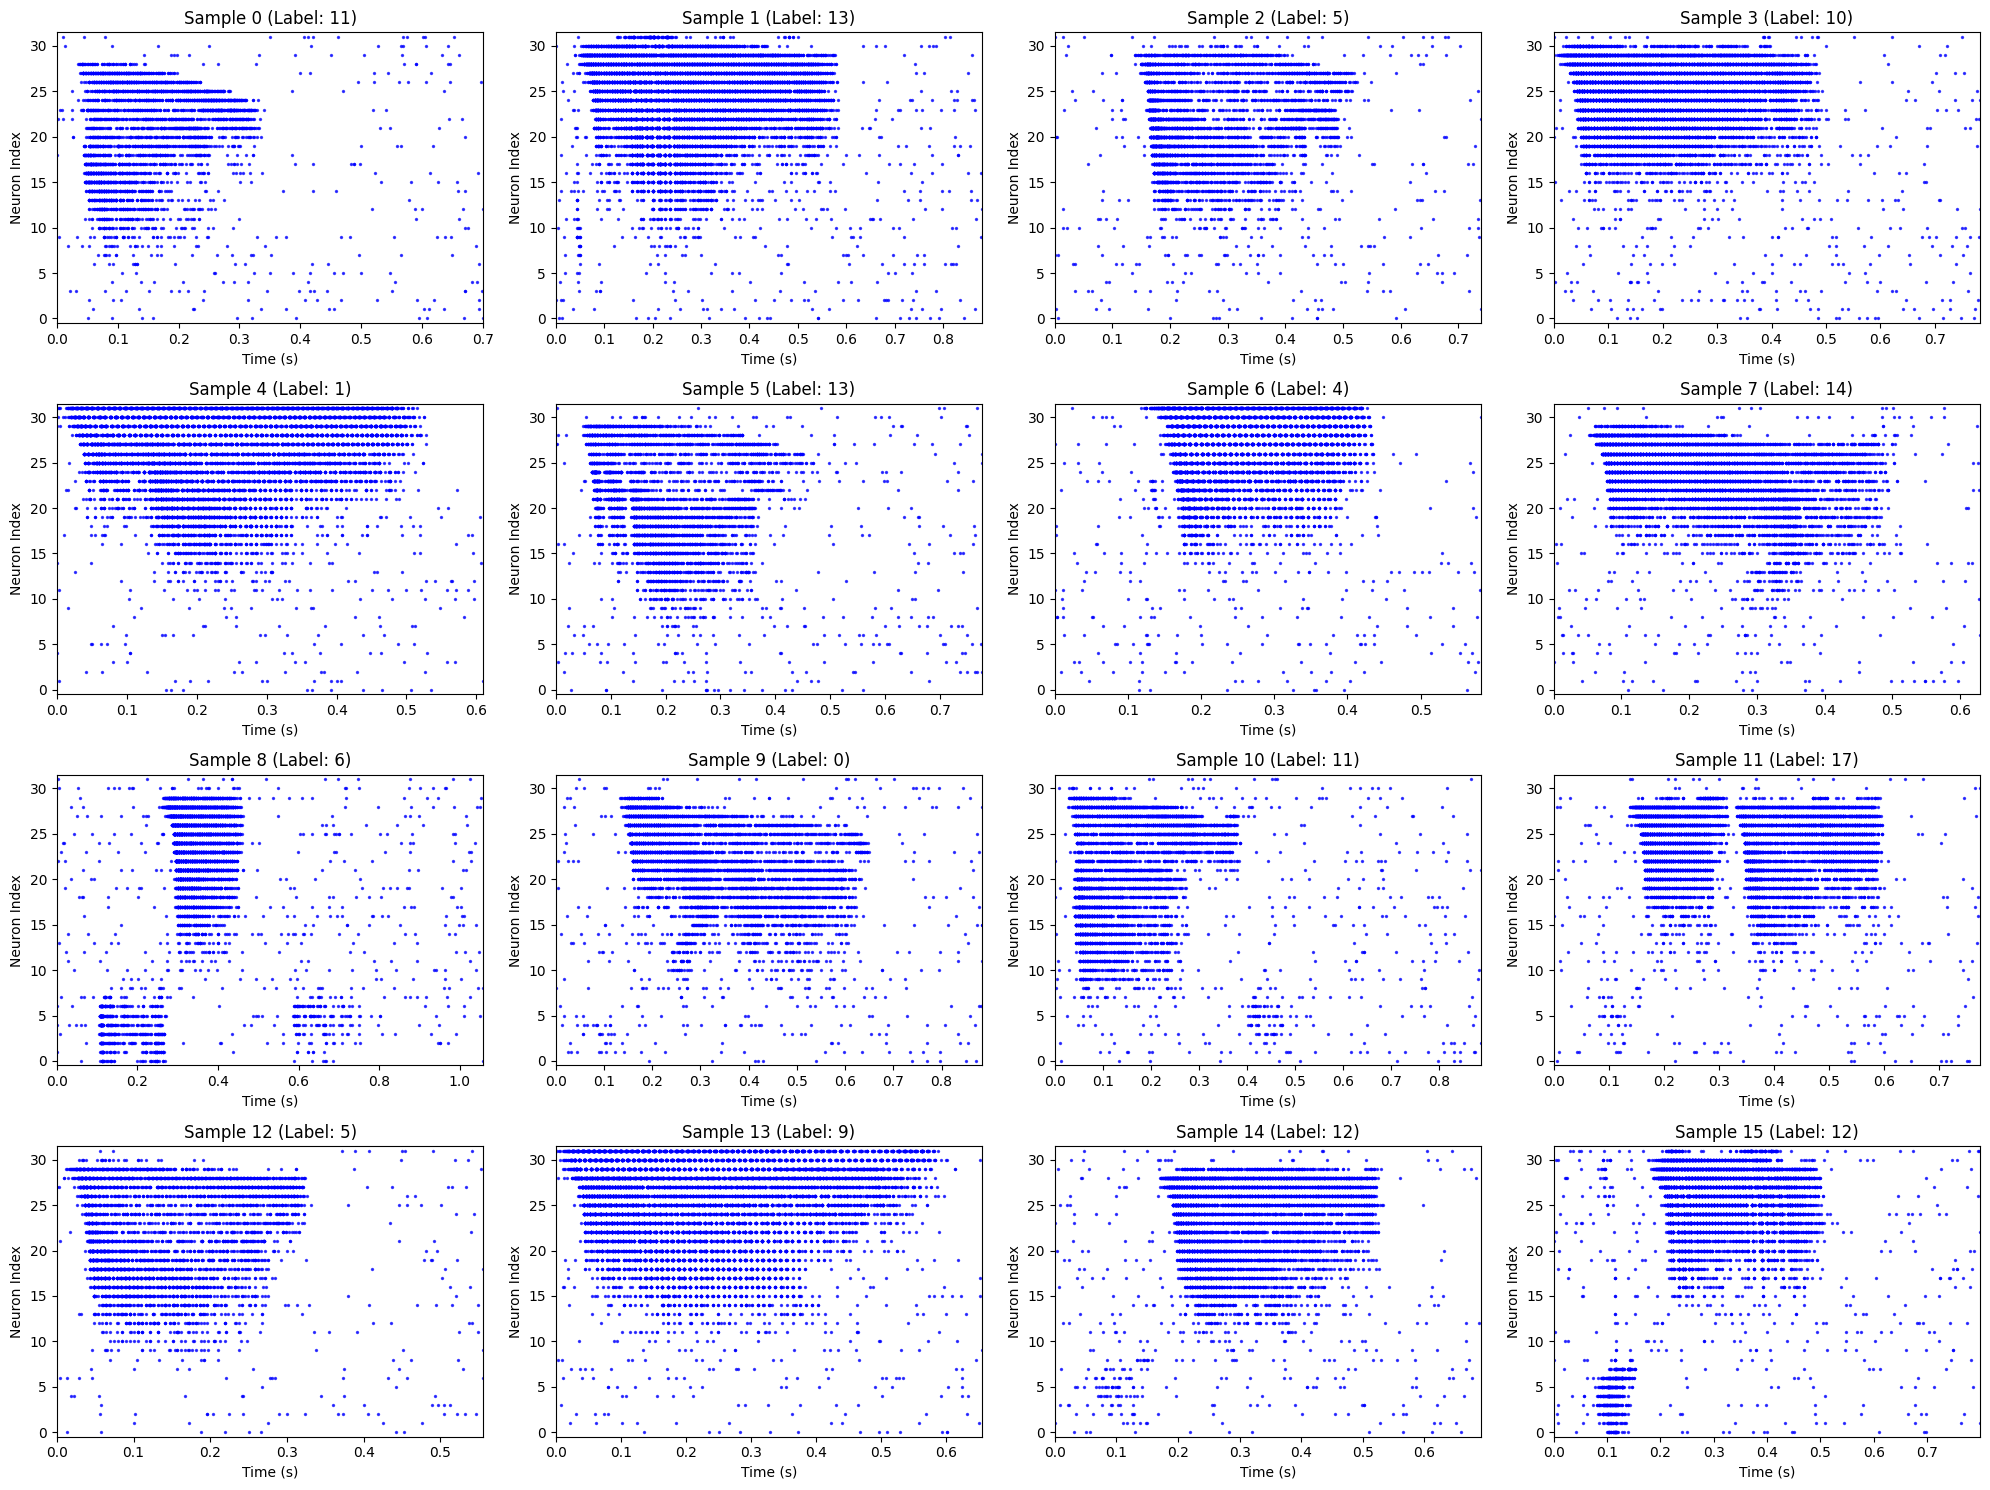

In [17]:
import tonic
from tonic import datasets
import matplotlib.pyplot as plt
import numpy as np

# SHD 데이터셋 로드
train_data = datasets.SHD(save_to=download_dir, train=True)

# 뉴런 인덱스 그룹화 함수
def group_neuron_indices(neuron_indices, total_channels, target_channels):
    """
    뉴런 인덱스를 그룹화하여 리매핑하는 함수.
    
    Args:
        neuron_indices (array-like): 기존 뉴런 인덱스 배열.
        total_channels (int): 원래 뉴런 채널 수.
        target_channels (int): 목표 뉴런 채널 수.
        
    Returns:
        array: 그룹화된 뉴런 인덱스 배열.
    """
    group_size = total_channels // target_channels
    return neuron_indices // group_size

# 시각화 함수
def visualize_shd_samples_with_group(data, num_samples=16, total_channels=700, target_channels=32):
    fig, axes = plt.subplots(4, 4, figsize=(20, 15))
    axes = axes.flatten()

    for idx in range(num_samples):
        events, label = data[idx]

        # 시간과 뉴런 인덱스 추출
        times = np.array([event[0] for event in events])  # time 추출
        neurons = np.array([event[1] for event in events])  # neuron_index 추출

        # 뉴런 인덱스 그룹화
        grouped_neurons = group_neuron_indices(neurons, total_channels, target_channels)

        ax = axes[idx]
        ax.scatter(times / 1e6, grouped_neurons, s=2, alpha=0.7, color='blue')  # μs → 초 변환
        ax.set_title(f"Sample {idx} (Label: {label})")
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Neuron Index")
        ax.set_xlim(0, max(times) / 1e6 if len(times) > 0 else 1)
        ax.set_ylim(-0.5, target_channels - 0.5)

    plt.tight_layout()
    plt.show()

# 시각화 실행
visualize_shd_samples_with_group(train_data)


In [8]:
# 데이터 구조 확인
for idx in range(1):  # 첫 번째 샘플만 확인
    events, label = train_data[idx]
    print(f"Sample {idx}:")
    print(f"Events type: {type(events)}")
    print(f"Events shape: {getattr(events, 'shape', 'No shape')}")
    print(f"Events data: {events[:10]}")  # 첫 10개 이벤트 출력
    print(f"Label: {label}")


Sample 0:
Events type: <class 'numpy.ndarray'>
Events shape: (4278,)
Events data: [(    0, 384, 1) ( 1832, 680, 1) ( 2166, 465, 1) ( 4123, 189, 1)
 ( 5542, 498, 1) ( 8460, 501, 1) ( 9872, 651, 1) (10124, 470, 1)
 (12664, 630, 1) (17837, 185, 1)]
Label: 11


In [ ]:
import tonic
from tonic import datasets
import struct
from tqdm import tqdm
import os
import numpy as np

# 뉴런 인덱스 그룹화 함수
def group_neuron_indices(neuron_indices, total_channels, target_channels):
    """
    뉴런 인덱스를 그룹화하여 리매핑하는 함수.
    
    Args:
        neuron_indices (array-like): 기존 뉴런 인덱스 배열.
        total_channels (int): 원래 뉴런 채널 수.
        target_channels (int): 목표 뉴런 채널 수.
        
    Returns:
        array: 그룹화된 뉴런 인덱스 배열.
    """
    group_size = total_channels // target_channels
    remainder = total_channels % target_channels
    
    # 나머지 뉴런을 버리거나 마지막 그룹에 포함
    result = []
    for idx in neuron_indices:
        if idx >= total_channels - remainder:  # 나머지 뉴런은 버림
            result.append(target_channels - 1)  # 마지막 그룹에 포함
        else:
            result.append(idx // group_size)
    
    return np.array(result)

# SHD 데이터셋 로드
train_data = datasets.SHD(save_to=download_dir, train=True)
test_data = datasets.SHD(save_to=download_dir, train=False)

def convert_to_bin_with_group(data, output_dir, total_channels=700, target_channels=32):
    """
    SHD 데이터셋을 .bin 파일로 변환하며 뉴런 인덱스를 그룹화하는 함수.
    
    Args:
        data (Dataset): Tonic 데이터셋 객체.
        output_dir (str): .bin 파일 저장 디렉토리.
        total_channels (int): 원래 뉴런 채널 수.
        target_channels (int): 목표 뉴런 채널 수.
    """
    for idx in tqdm(range(len(data)), desc="Converting to .bin"):
        events, label = data[idx]

        # 시간과 뉴런 인덱스 추출
        times = np.array([event[0] for event in events])  # time 추출
        neurons = np.array([event[1] for event in events])  # neuron_index 추출

        # 뉴런 인덱스 그룹화
        grouped_neurons = group_neuron_indices(neurons, total_channels, target_channels)

        # .bin 파일 경로 설정
        bin_file_path = f"{output_dir}/sample_{idx}.bin"

        with open(bin_file_path, 'wb') as bin_file:
            # 헤더 작성 (13 bytes)
            header = struct.pack(
                '>BHIIBB',
                label,          # Label index (1 byte)
                idx,            # Data index in category (2 bytes)
                idx + 1,        # Unique global ID (4 bytes)
                len(times),     # Number of data points (4 bytes)
                0,              # Reserved (1 byte)
                0               # Reserved (1 byte)
            )
            bin_file.write(header)

            # 스파이크 데이터 작성 (6 bytes per spike)
            for time, neuron in zip(times, grouped_neurons):
                packed_spike = struct.pack('>IH', int(time), int(neuron))
                bin_file.write(packed_spike)

# 출력 디렉토리 설정
output_dir_train = "./train_bin_grouped"
output_dir_test = "./test_bin_grouped"

# 디렉토리 생성
os.makedirs(output_dir_train, exist_ok=True)
os.makedirs(output_dir_test, exist_ok=True)

# 변환 실행
convert_to_bin_with_group(train_data, output_dir_train)
convert_to_bin_with_group(test_data, output_dir_test)


Converting to .bin: 100%|██████████| 2264/2264 [00:29<00:00, 77.77it/s]


In [26]:
# 특정 .bin 파일 경로 설정
bin_file_path = './train_bin_grouped/sample_0.bin'

# .bin 파일 읽기 및 출력
def read_and_print_bin_file(file_path):
    with open(file_path, 'rb') as f:
        # 헤더 읽기 (13 bytes)
        header_data = f.read(13)
        label, data_index, uid, num_points, r1, r2 = struct.unpack('>BHIIBB', header_data)
        
        print("Header Information:")
        print(f"Label: {label}")
        print(f"Data Index: {data_index}")
        print(f"Unique Global ID: {uid}")
        print(f"Number of Data Points: {num_points}")
        
        print("\nSpike Data (time in μs, neuron index):")
        for i in range(min(10, num_points)):  # 첫 10개 스파이크 출력
            spike_data = f.read(6)
            spike_time, neuron_index = struct.unpack('>IH', spike_data)
            print(f"Spike {i}: Time={spike_time} μs, Neuron Index={neuron_index}")

# 실행
read_and_print_bin_file(bin_file_path)


Header Information:
Label: 11
Data Index: 0
Unique Global ID: 1
Number of Data Points: 4278

Spike Data (time in μs, neuron index):
Spike 0: Time=0 μs, Neuron Index=18
Spike 1: Time=1832 μs, Neuron Index=31
Spike 2: Time=2166 μs, Neuron Index=22
Spike 3: Time=4123 μs, Neuron Index=9
Spike 4: Time=5542 μs, Neuron Index=23
Spike 5: Time=8460 μs, Neuron Index=23
Spike 6: Time=9872 μs, Neuron Index=31
Spike 7: Time=10124 μs, Neuron Index=22
Spike 8: Time=12664 μs, Neuron Index=30
Spike 9: Time=17837 μs, Neuron Index=8


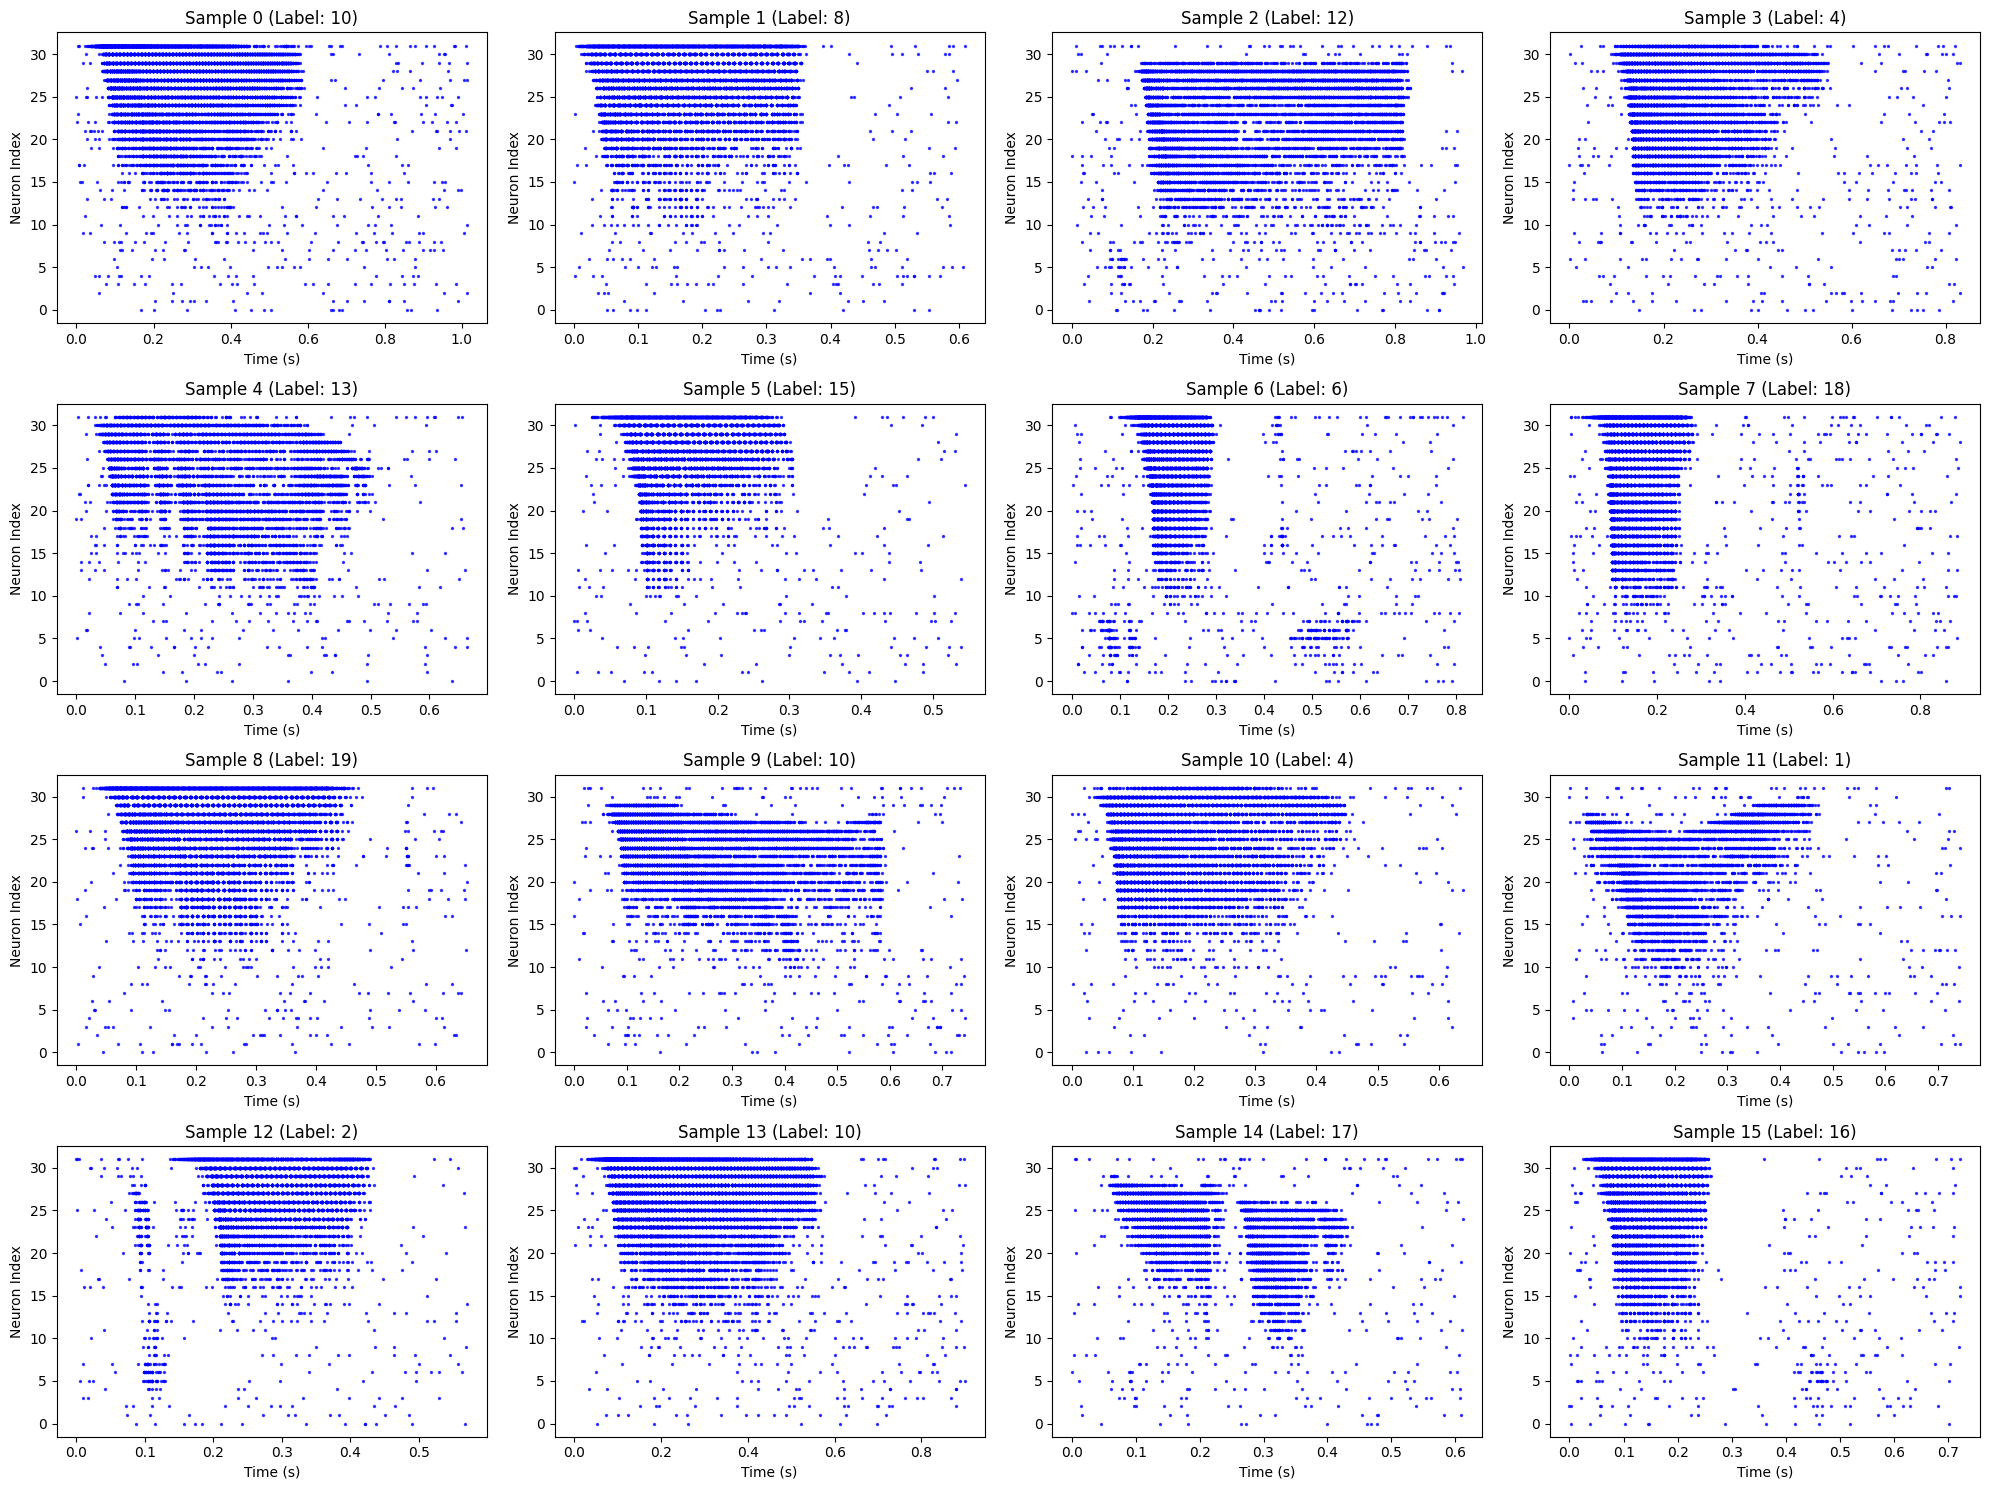

In [27]:
import struct
import matplotlib.pyplot as plt
import os

def read_bin_file(file_path):
    """
    .bin 파일을 읽어 데이터를 추출하는 함수.
    
    Args:
        file_path (str): .bin 파일 경로.
        
    Returns:
        dict: 헤더 정보와 스파이크 데이터.
    """
    with open(file_path, 'rb') as f:
        # 헤더 읽기 (13 bytes)
        header_data = f.read(13)
        header = struct.unpack('>BHIIBB', header_data)
        
        label = header[0]
        data_index = header[1]
        uid = header[2]
        num_points = header[3]

        # 스파이크 데이터 읽기
        spikes = []
        for _ in range(num_points):
            spike_data = f.read(6)
            spike_time, neuron_index = struct.unpack('>IH', spike_data)
            spikes.append((spike_time / 1e6, neuron_index))  # μs → 초 변환
        
        return {
            'label': label,
            'data_index': data_index,
            'uid': uid,
            'num_points': num_points,
            'spikes': spikes
        }

def visualize_bin_samples(bin_files, num_samples=16):
    """
    여러 .bin 파일의 스파이크 데이터를 시각화하는 함수.
    
    Args:
        bin_files (list): .bin 파일 경로 리스트.
        num_samples (int): 시각화할 샘플 수.
    """
    fig, axes = plt.subplots(4, 4, figsize=(20, 15))
    axes = axes.flatten()

    for idx, file_path in enumerate(bin_files[:num_samples]):  # 최대 num_samples개의 샘플 시각화
        data = read_bin_file(file_path)
        spikes = data['spikes']
        
        times = [s[0] for s in spikes]
        neurons = [s[1] for s in spikes]

        ax = axes[idx]
        ax.scatter(times, neurons, s=2, alpha=0.7, color='blue')
        ax.set_title(f"Sample {idx} (Label: {data['label']})")
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Neuron Index")
    
    plt.tight_layout()
    plt.show()

# 수정된 .bin 파일 경로 설정
output_dir_train = "./train_bin_grouped"
train_bin_files_grouped_fixed = [os.path.join(output_dir_train, f) for f in os.listdir(output_dir_train) if f.endswith('.bin')]

# 시각화 실행
visualize_bin_samples(train_bin_files_grouped_fixed)


In [30]:
import tonic
from tonic import datasets
import struct
from tqdm import tqdm
import os
import numpy as np

# 뉴런 인덱스 그룹화 함수
def group_neuron_indices(neuron_indices, total_channels, target_channels):
    """
    뉴런 인덱스를 그룹화하여 리매핑하는 함수.
    
    Args:
        neuron_indices (array-like): 기존 뉴런 인덱스 배열.
        total_channels (int): 원래 뉴런 채널 수.
        target_channels (int): 목표 뉴런 채널 수.
        
    Returns:
        array: 그룹화된 뉴런 인덱스 배열.
    """
    group_size = total_channels // target_channels
    remainder = total_channels % target_channels
    
    # 나머지 뉴런을 버리거나 마지막 그룹에 포함
    result = []
    for idx in neuron_indices:
        if idx >= total_channels - remainder:  # 나머지 뉴런은 버림
            result.append(target_channels - 1)  # 마지막 그룹에 포함
        else:
            result.append(idx // group_size)
    
    return np.array(result)

# SHD 데이터셋 로드
train_data = datasets.SHD(save_to=download_dir, train=True)
test_data = datasets.SHD(save_to=download_dir, train=False)

def convert_to_bin_with_group(data, output_dir, total_channels=700, target_channels=700):
    """
    SHD 데이터셋을 .bin 파일로 변환하며 뉴런 인덱스를 그룹화하는 함수.
    
    Args:
        data (Dataset): Tonic 데이터셋 객체.
        output_dir (str): .bin 파일 저장 디렉토리.
        total_channels (int): 원래 뉴런 채널 수.
        target_channels (int): 목표 뉴런 채널 수.
    """
    for idx in tqdm(range(len(data)), desc="Converting to .bin"):
        events, label = data[idx]

        # 시간과 뉴런 인덱스 추출
        times = np.array([event[0] for event in events])  # time 추출
        neurons = np.array([event[1] for event in events])  # neuron_index 추출

        # 뉴런 인덱스 그룹화
        grouped_neurons = group_neuron_indices(neurons, total_channels, target_channels)

        # .bin 파일 경로 설정
        bin_file_path = f"{output_dir}/sample_{idx}.bin"

        with open(bin_file_path, 'wb') as bin_file:
            # 헤더 작성 (13 bytes)
            header = struct.pack(
                '>BHIIBB',
                label,          # Label index (1 byte)
                idx,            # Data index in category (2 bytes)
                idx + 1,        # Unique global ID (4 bytes)
                len(times),     # Number of data points (4 bytes)
                0,              # Reserved (1 byte)
                0               # Reserved (1 byte)
            )
            bin_file.write(header)

            # 스파이크 데이터 작성 (6 bytes per spike)
            for time, neuron in zip(times, grouped_neurons):
                packed_spike = struct.pack('>IH', int(time), int(neuron))
                bin_file.write(packed_spike)

# 출력 디렉토리 설정
output_dir_train = "./train_bin"
output_dir_test = "./test_bin"

# 디렉토리 생성
os.makedirs(output_dir_train, exist_ok=True)
os.makedirs(output_dir_test, exist_ok=True)

# 변환 실행
convert_to_bin_with_group(train_data, output_dir_train)
convert_to_bin_with_group(test_data, output_dir_test)


Converting to .bin: 100%|██████████| 2264/2264 [00:29<00:00, 77.48it/s]


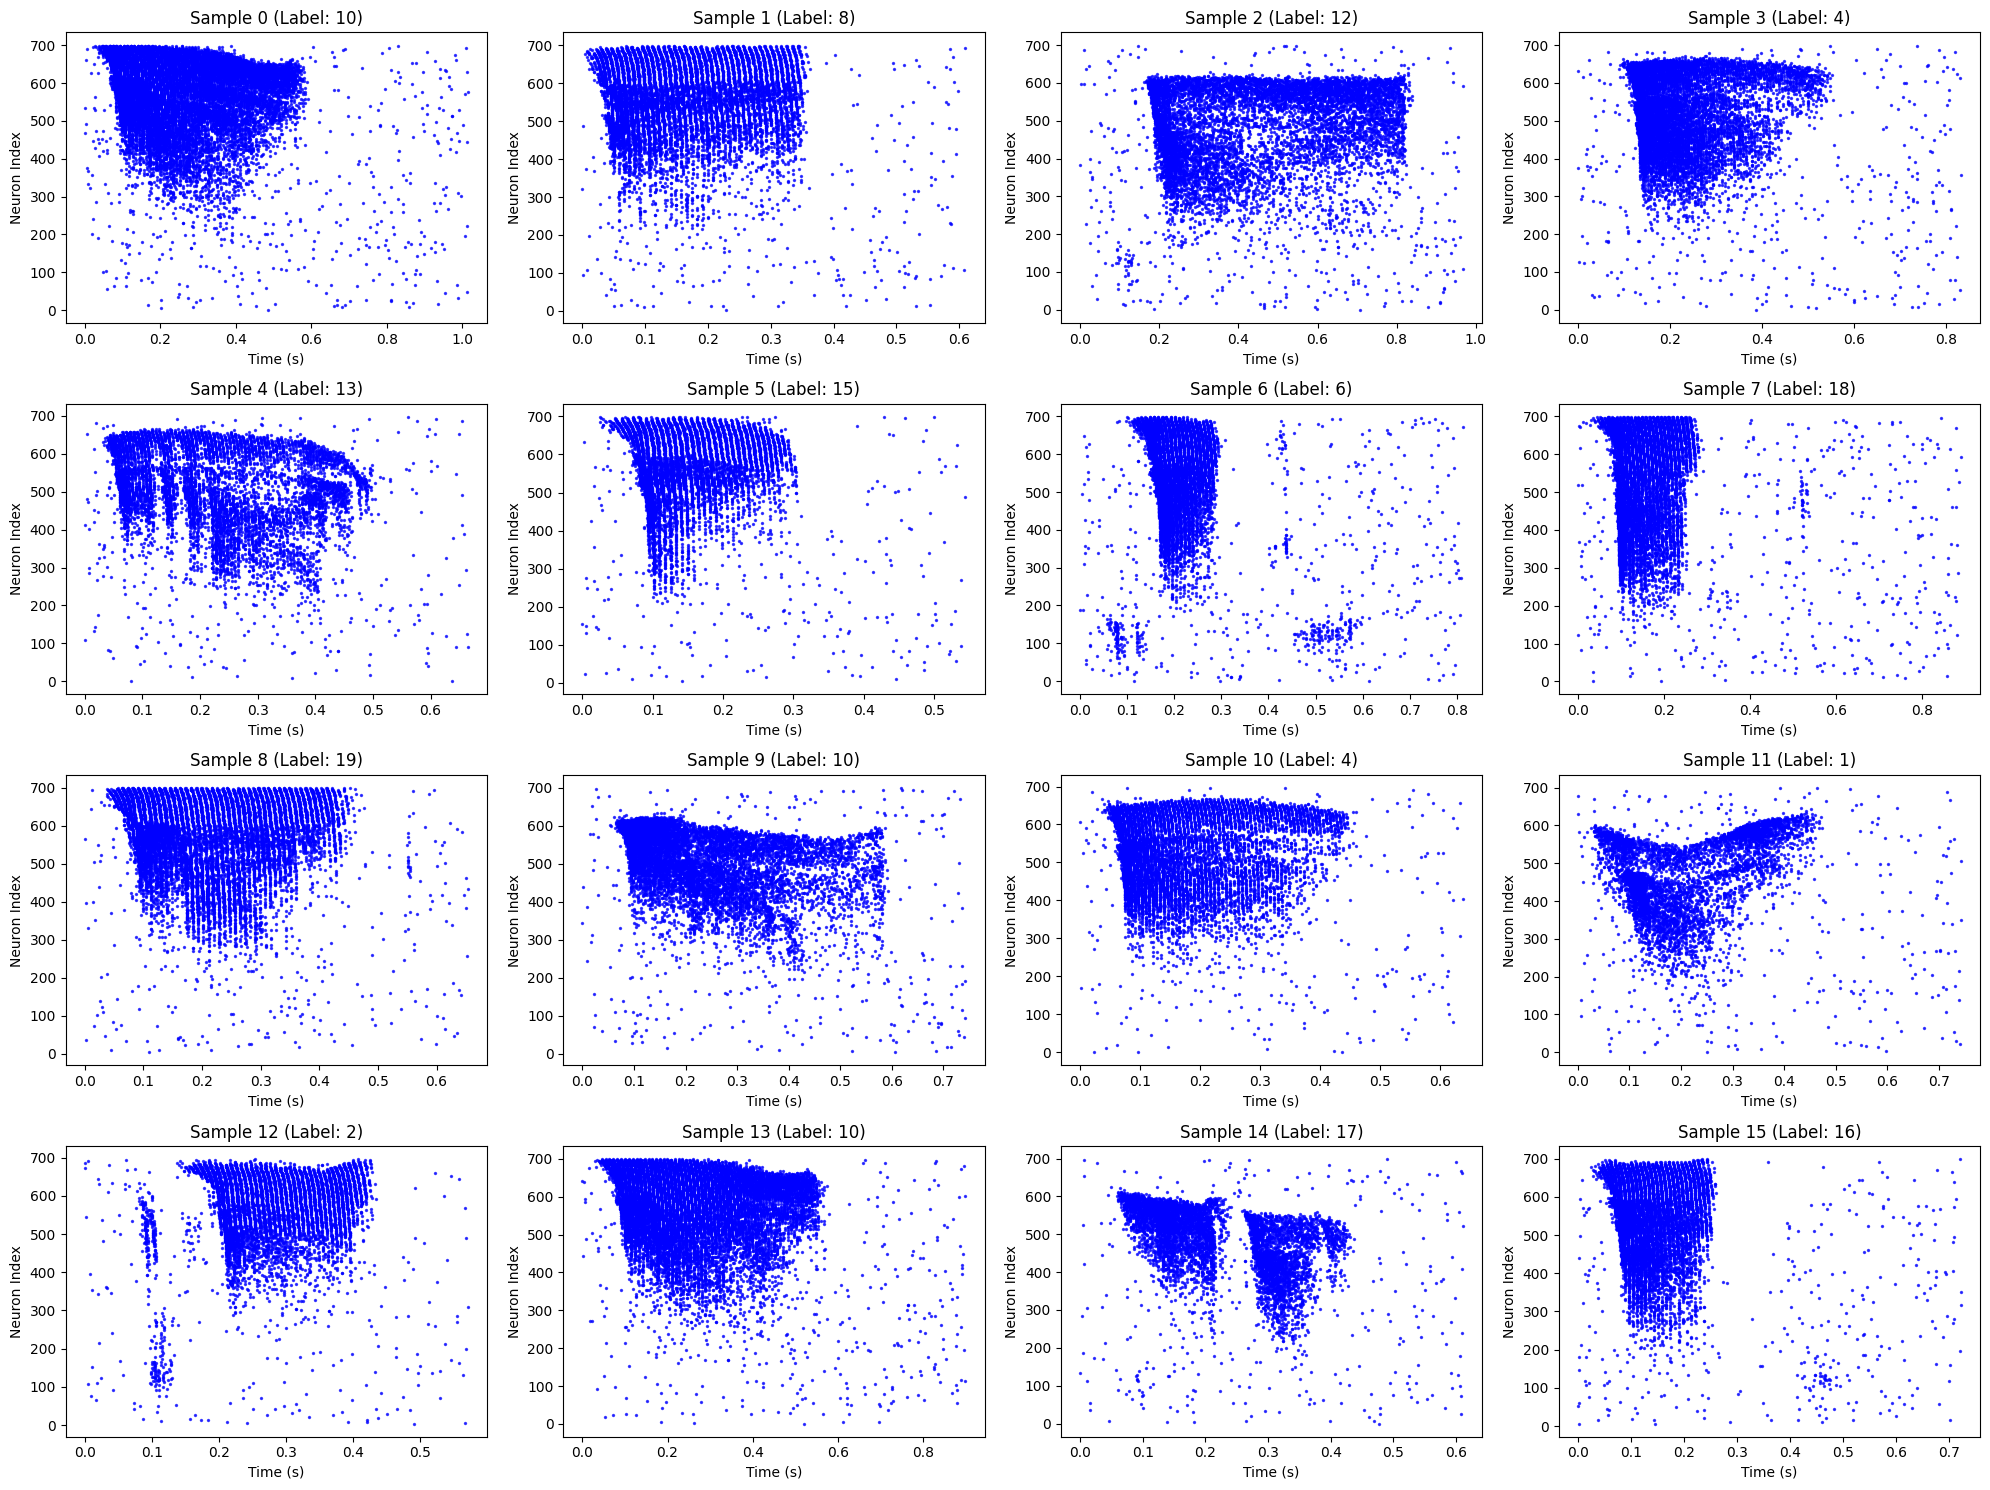

In [32]:
import struct
import matplotlib.pyplot as plt
import os

def read_bin_file(file_path):
    """
    .bin 파일을 읽어 데이터를 추출하는 함수.
    
    Args:
        file_path (str): .bin 파일 경로.
        
    Returns:
        dict: 헤더 정보와 스파이크 데이터.
    """
    with open(file_path, 'rb') as f:
        # 헤더 읽기 (13 bytes)
        header_data = f.read(13)
        header = struct.unpack('>BHIIBB', header_data)
        
        label = header[0]
        data_index = header[1]
        uid = header[2]
        num_points = header[3]

        # 스파이크 데이터 읽기
        spikes = []
        for _ in range(num_points):
            spike_data = f.read(6)
            spike_time, neuron_index = struct.unpack('>IH', spike_data)
            spikes.append((spike_time / 1e6, neuron_index))  # μs → 초 변환
        
        return {
            'label': label,
            'data_index': data_index,
            'uid': uid,
            'num_points': num_points,
            'spikes': spikes
        }

def visualize_bin_samples(bin_files, num_samples=16):
    """
    여러 .bin 파일의 스파이크 데이터를 시각화하는 함수.
    
    Args:
        bin_files (list): .bin 파일 경로 리스트.
        num_samples (int): 시각화할 샘플 수.
    """
    fig, axes = plt.subplots(4, 4, figsize=(20, 15))
    axes = axes.flatten()

    for idx, file_path in enumerate(bin_files[:num_samples]):  # 최대 num_samples개의 샘플 시각화
        data = read_bin_file(file_path)
        spikes = data['spikes']
        
        times = [s[0] for s in spikes]
        neurons = [s[1] for s in spikes]

        ax = axes[idx]
        ax.scatter(times, neurons, s=2, alpha=0.7, color='blue')
        ax.set_title(f"Sample {idx} (Label: {data['label']})")
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Neuron Index")
    
    plt.tight_layout()
    plt.show()

# 수정된 .bin 파일 경로 설정
output_dir_train = "./train_bin"
train_bin_files_grouped_fixed = [os.path.join(output_dir_train, f) for f in os.listdir(output_dir_train) if f.endswith('.bin')]

# 시각화 실행
visualize_bin_samples(train_bin_files_grouped_fixed)


In [18]:
import os
import struct
import random
from tqdm import tqdm
import numpy as np
from tonic import datasets

# ---------- parameters ----------
download_dir    = "/home/sungminlee/speakmin/run"  # .h5 파일 위치
train_out_dir   = "./train"                        # train*.bin 저장 폴더
test_out_dir    = "./test"                         # test0.bin 저장 폴더
total_channels  = 700
target_channels = 64
train_parts     = 10
rng_seed        = 42
# ----------------------------------

def group_neuron_indices(neuron_indices, total_channels, target_channels):
    group_size = total_channels // target_channels
    remainder  = total_channels %  target_channels
    mapped = neuron_indices // group_size
    if remainder:
        mask = neuron_indices >= total_channels - remainder
        mapped[mask] = target_channels - 1
    return mapped.astype(np.uint16)

def open_bins(directory, prefix, parts):
    os.makedirs(directory, exist_ok=True)
    return {i: open(os.path.join(directory, f"{prefix}{i}.bin"), "wb")
            for i in range(parts)}

def close_bins(handles):
    for fh in handles.values():
        fh.close()

def write_sample(fh, times, neurons, label, global_id, local_id):
    n = len(times)
    # 13-byte header
    header = struct.pack(">BHIIBB",
                         label,     # 1 byte
                         local_id,  # 2 bytes (샘플 인덱스)
                         global_id, # 4 bytes (고유 ID)
                         n,         # 4 bytes (스파이크 개수)
                         0, 0)      # 2 bytes 예약
    fh.write(header)
    # 6-byte 이벤트 데이터 순차 저장 (times then neurons)
    fh.write(struct.pack(f">{n}I", *times))
    fh.write(struct.pack(f">{n}H", *neurons))

def convert_split(dataset, out_dir, prefix, parts, shuffle, rng):
    bins = open_bins(out_dir, prefix, parts)
    per_file_count = [0]*parts
    global_id = 0

    indices = list(range(len(dataset)))
    if shuffle:
        rng.shuffle(indices)

    for k, idx in enumerate(tqdm(indices, desc=f"Packing {prefix}")):
        events_raw, label = dataset[idx]
        times = events_raw['t'].astype(np.uint32)
        neurons = events_raw['x'].astype(np.uint32)
        neurons = group_neuron_indices(neurons, total_channels, target_channels)

        file_id = k % parts
        write_sample(
            bins[file_id],
            times, neurons,
            label,
            global_id,
            per_file_count[file_id]
        )
        per_file_count[file_id] += 1
        global_id += 1

    close_bins(bins)
    print(f"{prefix}: samples per file → {per_file_count}")

if __name__ == "__main__":
    rng = random.Random(rng_seed)
    train_ds = datasets.SHD(save_to=download_dir, train=True)
    test_ds  = datasets.SHD(save_to=download_dir, train=False)

    # 10개 train 파일
    convert_split(train_ds,
                  out_dir=train_out_dir,
                  prefix="train",
                  parts=train_parts,
                  shuffle=True,
                  rng=rng)

    # 1개 test 파일
    convert_split(test_ds,
                  out_dir=test_out_dir,
                  prefix="test",
                  parts=1,
                  shuffle=False,
                  rng=rng)


Packing train: 100%|██████████| 8156/8156 [01:17<00:00, 105.85it/s]


train: samples per file → [816, 816, 816, 816, 816, 816, 815, 815, 815, 815]


Packing test: 100%|██████████| 2264/2264 [00:22<00:00, 102.84it/s]

test: samples per file → [2264]


In [15]:
# 셀: 생성된 train*.bin 파일 확인 스크립트
import os
import struct
from pprint import pprint

train_dir = "/home/sungminlee/speakmin/run/train"
# 1) 파일 리스트
bin_files = sorted(f for f in os.listdir(train_dir) if f.startswith("train") and f.endswith(".bin"))
print("Found files:", bin_files)

summary = {}
for fname in bin_files:
    path = os.path.join(train_dir, fname)
    with open(path, "rb") as f:
        # 2) 헤더 읽기
        label, local_id, global_id, n_spikes, _, _ = struct.unpack(">BHIIBB", f.read(13))
        # 3) 앞 5개 스파이크만 읽어 보기
        first_spikes = [struct.unpack(">IH", f.read(6)) for _ in range(min(5, n_spikes))]
    summary[fname] = {
        "label": label,
        "local_id": local_id,
        "global_id": global_id,
        "n_spikes": n_spikes,
        "first_spikes": first_spikes
    }

# 4) 결과 출력
pprint(summary)


Found files: ['train0.bin', 'train1.bin', 'train2.bin', 'train3.bin', 'train4.bin', 'train5.bin', 'train6.bin', 'train7.bin', 'train8.bin', 'train9.bin']
{'train0.bin': {'first_spikes': [(0, 0),
                                 (16384000, 500),
                                 (4039, 0),
                                 (292225024, 4749),
                                 (6916, 0)],
                'global_id': 0,
                'label': 4,
                'local_id': 0,
                'n_spikes': 7491},
 'train1.bin': {'first_spikes': [(0, 0),
                                 (5439488, 2040),
                                 (4959, 0),
                                 (365953024, 8872),
                                 (9544, 0)],
                'global_id': 1,
                'label': 6,
                'local_id': 0,
                'n_spikes': 6030},
 'train2.bin': {'first_spikes': [(0, 0),
                                 (150077440, 3749),
                                 (674

In [17]:
# 셀: train0.bin 앞 10개 샘플 읽기 + 시각화
import struct
import os
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# 1) 한글 폰트 설정 (필요시)
import matplotlib.font_manager as fm
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"  # 시스템에 맞게 수정
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

# 2) 샘플 읽기 함수
def read_next_sample(f):
    hdr = f.read(13)
    if len(hdr) < 13:
        return None
    label, local_id, global_id, n_spikes, _, _ = struct.unpack(">BHIIBB", hdr)
    times, neurons = [], []
    for _ in range(n_spikes):
        data = f.read(6)
        if len(data) < 6:
            break
        t, n = struct.unpack(">IH", data)
        times.append(t / 1e6)   # μs → s
        neurons.append(n)
    return label, times, neurons

# 3) train0.bin 경로
train0 = "/home/sungminlee/speakmin/run/train/train0.bin"
assert os.path.exists(train0), "train0.bin 파일을 찾을 수 없습니다"

# 4) 앞 10개 샘플 읽기
samples = []
with open(train0, "rb") as f:
    for _ in range(10):
        s = read_next_sample(f)
        if s is None:
            break
        samples.append(s)

# 5) 2×5 그리드 시각화
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for idx, (label, times, neurons) in enumerate(samples):
    ax = axes[idx]
    ax.scatter(times, neurons, s=3, alpha=0.7, c='C0')
    ax.set_title(f"샘플 {idx} (라벨: {label})")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Neuron idx")
    ax.set_ylim(-1, max(neurons)+1)
    ax.grid(True, linestyle='--', alpha=0.3)

# 남은 축 숨기기
for ax in axes[len(samples):]:
    ax.axis('off')

plt.tight_layout()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

In [22]:
# Jupyter‐ready script: Convert SHD → .bin matching C++ reader’s format
import os
import struct
import random
from tqdm.notebook import tqdm
import numpy as np
from tonic import datasets

# ───── parameters ────────────────────────────────────────────────────────────
download_dir    = "/home/sungminlee/speakmin/run"   # contains shd_train.h5 / shd_test.h5
train_out_dir   = "./train"                        # will hold train0.bin…train9.bin
test_out_dir    = "./test"                         # will hold test0.bin
total_channels  = 700
target_channels = 64
train_parts     = 10
rng_seed        = 42
# ─────────────────────────────────────────────────────────────────────────────

def group_neuron_indices(neuron_idx: np.ndarray,
                         total: int,
                         target: int) -> np.ndarray:
    """
    Uniformly map 0…total-1 → 0…target-1.  Extra channels fold into last group.
    """
    gs = total // target
    rem = total % target
    mapped = neuron_idx // gs
    if rem:
        mask = neuron_idx >= total - rem
        mapped[mask] = target - 1
    return mapped.astype(np.uint16)

def write_sample(fh, label, cat_index, global_id, times, neurons):
    """
    Pack one sample:
     • Unsigned char  label (1B)
     • Unsigned short cat_index (2B) – sample index *within its label*
     • Unsigned int   global_id (4B)
     • Unsigned int   N_spikes  (4B)
     • uchar reserved1 (1B)
     • uchar reserved2 (1B)
     • then for each spike:
         – uint32 time (4B)
         – uint16 neuron (2B)
    """
    n = len(times)
    # header
    hdr = struct.pack(
        ">BHIIBB",
        int(label),
        int(cat_index),
        int(global_id),
        int(n),
        0, 0
    )
    fh.write(hdr)
    # payload: times then neurons
    fh.write(struct.pack(f">{n}I", *times))
    fh.write(struct.pack(f">{n}H", *neurons))

def convert_split(ds, out_dir, prefix, parts, shuffle, rng):
    os.makedirs(out_dir, exist_ok=True)
    # open bin files
    files = {i: open(f"{out_dir}/{prefix}{i}.bin", "wb") for i in range(parts)}
    per_label_count = {lbl: 0 for lbl in range(20)}
    per_file_count  = [0]*parts
    gid = 0
    idxs = list(range(len(ds)))
    if shuffle: rng.shuffle(idxs)

    for k, idx in enumerate(tqdm(idxs, desc=f"Packing {prefix}")):
        events_raw, label = ds[idx]
        # extract fields
        times   = events_raw['t'].astype(np.uint32)
        neurons = events_raw['x'].astype(np.uint32)
        neurons = group_neuron_indices(neurons, total_channels, target_channels)
        # determine which file
        fid = k % parts
        # category index = per‐label counter BEFORE increment
        cat_idx = per_label_count[label]
        write_sample(files[fid],
                     label,
                     cat_idx,
                     gid,
                     times,
                     neurons)
        # increment counters
        per_label_count[label] += 1
        per_file_count[fid] += 1
        gid += 1

    # close
    for fh in files.values(): fh.close()
    print(f"{prefix}: per-file counts → {per_file_count}")

if __name__ == "__main__":
    rng = random.Random(rng_seed)
    # load SHD
    train_ds = datasets.SHD(save_to=download_dir, train=True)
    test_ds  = datasets.SHD(save_to=download_dir, train=False)

    # convert
    convert_split(train_ds,
                  out_dir=train_out_dir,
                  prefix="train",
                  parts=train_parts,
                  shuffle=True,
                  rng=rng)
    convert_split(test_ds,
                  out_dir=test_out_dir,
                  prefix="test",
                  parts=1,
                  shuffle=False,
                  rng=rng)


Packing train:   0%|          | 0/8156 [00:00<?, ?it/s]

train: per-file counts → [816, 816, 816, 816, 816, 816, 815, 815, 815, 815]


Packing test:   0%|          | 0/2264 [00:00<?, ?it/s]

test: per-file counts → [2264]


/tmp/ipykernel_2052873/2308656734.py:50: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2052873/2308656734.py:50: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2052873/2308656734.py:50: UserWarning: Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2052873/2308656734.py:50: UserWarning: Glyph 48296 (\N{HANGUL SYLLABLE BEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2052873/2308656734.py:50: UserWarning: Glyph 52852 (\N{HANGUL SYLLABLE KA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2052873/2308656734.py:50: UserWarning: Glyph 53580 (\N{HANGUL SYLLABLE TE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2052873/2308656734.py:50: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu 

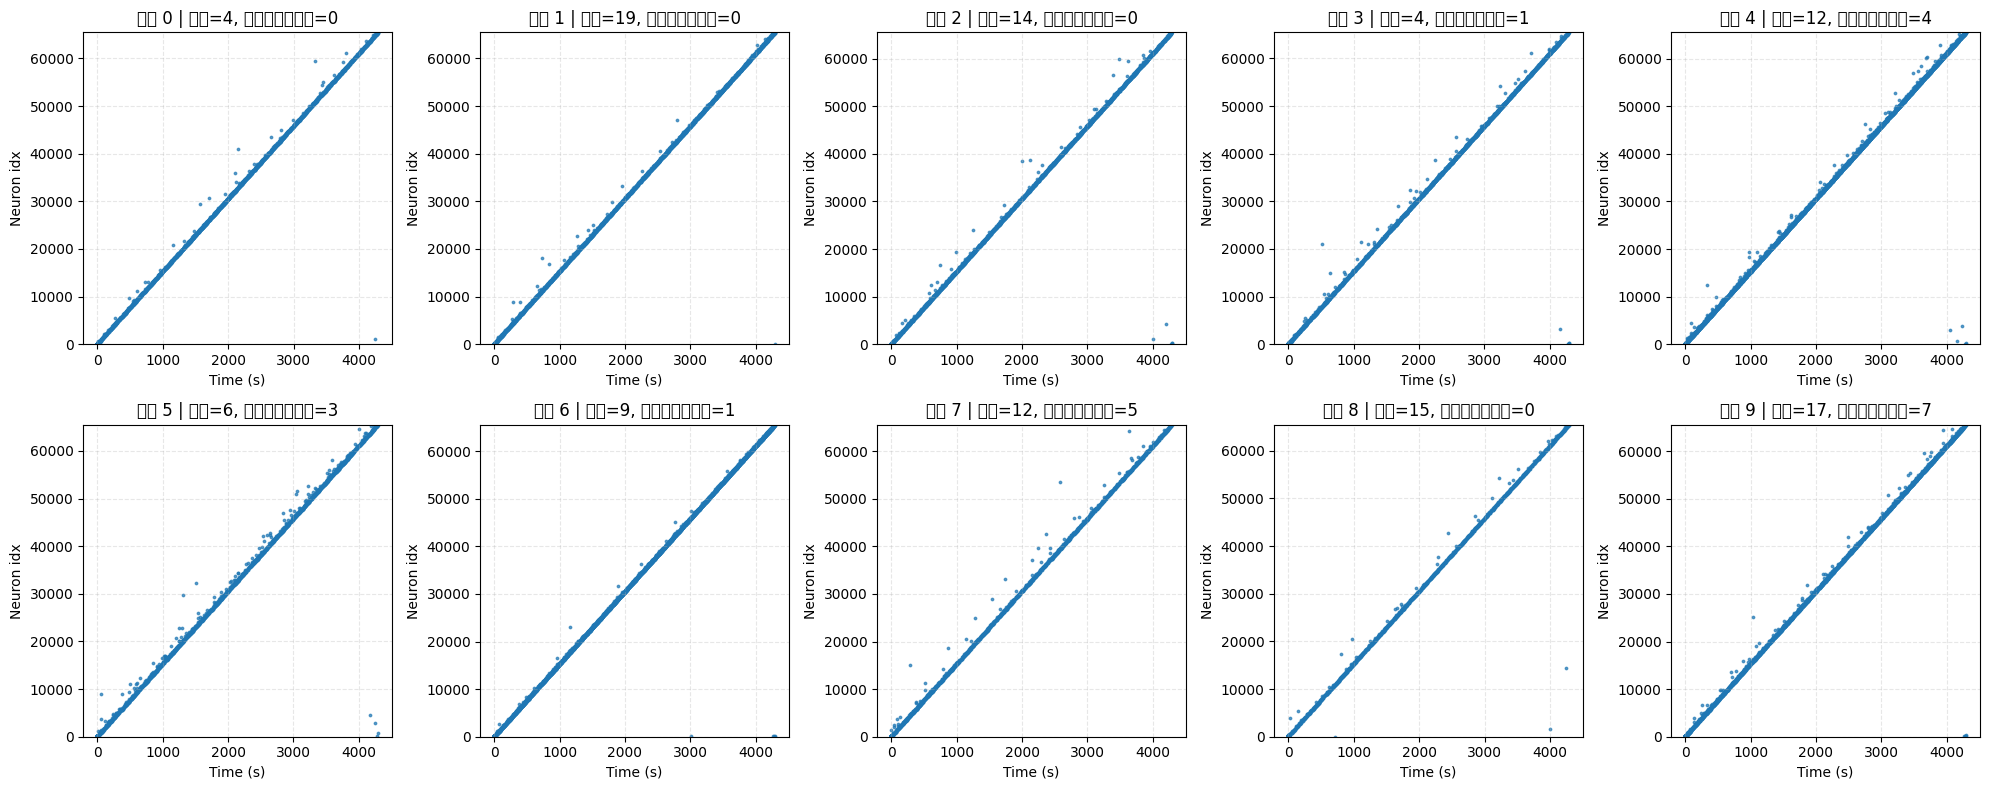

In [24]:
# 셀 1: 라이브러리 임포트 및 설정
import os
import struct
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# 셀 2: C++ 포맷 그대로 읽는 함수
def read_next_sample(f):
    hdr = f.read(13)
    if len(hdr) < 13:
        return None
    # >BHIIBB: uchar, ushort, uint, uint, uchar, uchar
    label, cat_idx, gid, n_spikes, _, _ = struct.unpack(">BHIIBB", hdr)
    times, neurons = [], []
    for _ in range(n_spikes):
        data = f.read(6)
        if len(data) < 6:
            break
        t, n = struct.unpack(">IH", data)
        times.append(t / 1e6)     # μs → s
        neurons.append(n)
    return label, cat_idx, gid, times, neurons

# 셀 3: 첫 10개 샘플 읽기 + 시각화
train0 = "/home/sungminlee/speakmin/run/train/train0.bin"
assert os.path.exists(train0), "train0.bin 파일을 찾을 수 없습니다"

samples = []
with open(train0, "rb") as f:
    for _ in range(10):
        s = read_next_sample(f)
        if s is None:
            break
        samples.append(s)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for idx, (label, cat_idx, gid, times, neurons) in enumerate(samples):
    ax = axes[idx]
    ax.scatter(times, neurons, s=3, alpha=0.7, color='C0')
    ax.set_title(f"샘플 {idx} | 라벨={label}, 카테고리인덱스={cat_idx}")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Neuron idx")
    ax.set_ylim(-1, max(neurons)+1)
    ax.grid(True, linestyle='--', alpha=0.3)

for ax in axes[len(samples):]:
    ax.axis('off')

plt.tight_layout()
plt.show()


In [28]:
import os
import struct
import random
from tqdm import tqdm
import numpy as np
from tonic import datasets

# ───────── USER PARAMETERS ───────────────────────────────────────────────────
DOWNLOAD_DIR    = "/home/sungminlee/speakmin/run"   # contains shd_train.h5 / shd_test.h5
TRAIN_OUT_DIR   = "./train"                        # will hold train0.bin…train9.bin
TEST_OUT_DIR    = "./test"                         # will hold test0.bin
TOTAL_CHANNELS  = 700
TARGET_CHANNELS = 64
TRAIN_PARTS     = 10
RNG_SEED        = 42
# ─────────────────────────────────────────────────────────────────────────────

def group_neuron_indices(neuron_idx: np.ndarray,
                         total: int,
                         target: int) -> np.ndarray:
    """
    Uniformly map 0…total-1 → 0…target-1. Extras fold into last group.
    """
    gs = total // target
    rem = total % target
    mapped = neuron_idx // gs
    if rem:
        mask = neuron_idx >= total - rem
        mapped[mask] = target - 1
    return mapped.astype(np.uint16)

def write_sample(fh, label, data_index, global_id, times, neurons):
    """
    Pack one sample to 'fh' matching C++ reader:
      >BHIIBB  + N×(>IH)
    """
    n = len(times)
    # 13-byte header
    hdr = struct.pack(">BHIIBB",
                      int(label),
                      int(data_index),
                      int(global_id),
                      int(n),
                      0, 0)
    fh.write(hdr)
    # payload: all times then all neurons
    payload = np.column_stack((times, neurons)).ravel()
    fmt = ">" + "IH" * n
    fh.write(struct.pack(fmt, *payload))

def convert_split(ds, out_dir, prefix, parts, shuffle, rng):
    os.makedirs(out_dir, exist_ok=True)
    # open handles
    files = {i: open(f"{out_dir}/{prefix}{i}.bin", "wb") for i in range(parts)}
    per_label_count = {}   # dynamic per-label counter
    per_file_count  = [0]*parts
    gid = 0

    indices = list(range(len(ds)))
    if shuffle:
        rng.shuffle(indices)

    for k, idx in enumerate(tqdm(indices, desc=f"Packing {prefix}")):
        events, label = ds[idx]
        times   = events['t'].astype(np.uint32)
        neurons = group_neuron_indices(events['x'].astype(np.uint32),
                                       TOTAL_CHANNELS,
                                       TARGET_CHANNELS)

        # category index within true label
        data_index = per_label_count.get(label, 0)

        # choose shard
        fid = k % parts
        write_sample(files[fid],
                     label,
                     data_index,
                     gid,
                     times,
                     neurons)

        per_label_count[label] = data_index + 1
        per_file_count[fid] += 1
        gid += 1

    # close
    for fh in files.values():
        fh.close()

    print(f"{prefix}: samples per file → {per_file_count}")

if __name__ == "__main__":
    rng = random.Random(RNG_SEED)
    # load SHD
    train_ds = datasets.SHD(save_to=DOWNLOAD_DIR, train=True)
    test_ds  = datasets.SHD(save_to=DOWNLOAD_DIR, train=False)

    # create shards
    convert_split(train_ds,
                  out_dir=TRAIN_OUT_DIR,
                  prefix="train",
                  parts=TRAIN_PARTS,
                  shuffle=True,
                  rng=rng)

    convert_split(test_ds,
                  out_dir=TEST_OUT_DIR,
                  prefix="test",
                  parts=1,
                  shuffle=False,
                  rng=rng)


Packing train:   0%|          | 0/8156 [00:00<?, ?it/s]

Packing train: 100%|██████████| 8156/8156 [01:21<00:00, 100.33it/s]


train: samples per file → [816, 816, 816, 816, 816, 816, 815, 815, 815, 815]


Packing test: 100%|██████████| 2264/2264 [00:21<00:00, 106.29it/s]

test: samples per file → [2264]


In [29]:
import struct
f = open("train/train0.bin","rb")
hdr = struct.unpack(">BHIIBB", f.read(13))
print("Header:", hdr)  # (label, data_index, gid, n_spikes,0,0)
spk = [struct.unpack(">IH", f.read(6)) for _ in range(min(5, hdr[3]))]
print("First 5 spikes:", spk)


Header: (4, 0, 0, 7491, 0, 0)
First 5 spikes: [(0, 11), (250, 33), (500, 33), (4039, 58), (4459, 50)]


In [30]:
import os
import struct
import random
from tqdm import tqdm
import numpy as np
from tonic import datasets

# ───────── USER PARAMETERS ───────────────────────────────────────────────────
DOWNLOAD_DIR    = "/home/sungminlee/speakmin/run"   # contains shd_train.h5 / shd_test.h5
TRAIN_OUT_DIR   = "./SHD_700"                        # will hold train0.bin…train9.bin
TEST_OUT_DIR    = "./SHD_700"                         # will hold test0.bin
TOTAL_CHANNELS  = 700
TARGET_CHANNELS = 700
TRAIN_PARTS     = 10
RNG_SEED        = 42
# ─────────────────────────────────────────────────────────────────────────────

def group_neuron_indices(neuron_idx: np.ndarray,
                         total: int,
                         target: int) -> np.ndarray:
    """
    Uniformly map 0…total-1 → 0…target-1. Extras fold into last group.
    """
    gs = total // target
    rem = total % target
    mapped = neuron_idx // gs
    if rem:
        mask = neuron_idx >= total - rem
        mapped[mask] = target - 1
    return mapped.astype(np.uint16)

def write_sample(fh, label, data_index, global_id, times, neurons):
    """
    Pack one sample to 'fh' matching C++ reader:
      >BHIIBB  + N×(>IH)
    """
    n = len(times)
    # 13-byte header
    hdr = struct.pack(">BHIIBB",
                      int(label),
                      int(data_index),
                      int(global_id),
                      int(n),
                      0, 0)
    fh.write(hdr)
    # payload: all times then all neurons
    payload = np.column_stack((times, neurons)).ravel()
    fmt = ">" + "IH" * n
    fh.write(struct.pack(fmt, *payload))

def convert_split(ds, out_dir, prefix, parts, shuffle, rng):
    os.makedirs(out_dir, exist_ok=True)
    # open handles
    files = {i: open(f"{out_dir}/{prefix}{i}.bin", "wb") for i in range(parts)}
    per_label_count = {}   # dynamic per-label counter
    per_file_count  = [0]*parts
    gid = 0

    indices = list(range(len(ds)))
    if shuffle:
        rng.shuffle(indices)

    for k, idx in enumerate(tqdm(indices, desc=f"Packing {prefix}")):
        events, label = ds[idx]
        times   = events['t'].astype(np.uint32)
        neurons = group_neuron_indices(events['x'].astype(np.uint32),
                                       TOTAL_CHANNELS,
                                       TARGET_CHANNELS)

        # category index within true label
        data_index = per_label_count.get(label, 0)

        # choose shard
        fid = k % parts
        write_sample(files[fid],
                     label,
                     data_index,
                     gid,
                     times,
                     neurons)

        per_label_count[label] = data_index + 1
        per_file_count[fid] += 1
        gid += 1

    # close
    for fh in files.values():
        fh.close()

    print(f"{prefix}: samples per file → {per_file_count}")

if __name__ == "__main__":
    rng = random.Random(RNG_SEED)
    # load SHD
    train_ds = datasets.SHD(save_to=DOWNLOAD_DIR, train=True)
    test_ds  = datasets.SHD(save_to=DOWNLOAD_DIR, train=False)

    # create shards
    convert_split(train_ds,
                  out_dir=TRAIN_OUT_DIR,
                  prefix="train",
                  parts=TRAIN_PARTS,
                  shuffle=True,
                  rng=rng)

    convert_split(test_ds,
                  out_dir=TEST_OUT_DIR,
                  prefix="test",
                  parts=1,
                  shuffle=False,
                  rng=rng)


Packing train: 100%|██████████| 8156/8156 [02:51<00:00, 47.50it/s]


train: samples per file → [816, 816, 816, 816, 816, 816, 815, 815, 815, 815]


Packing test: 100%|██████████| 2264/2264 [00:30<00:00, 74.01it/s]

test: samples per file → [2264]


In [31]:
import os
import struct
import random
from tqdm import tqdm
import numpy as np
from tonic import datasets

# ───────── USER PARAMETERS ───────────────────────────────────────────────────
DOWNLOAD_DIR    = "/home/sungminlee/speakmin/run"   # contains shd_train.h5 / shd_test.h5
TRAIN_OUT_DIR   = "./SHD_350"                        # will hold train0.bin…train9.bin
TEST_OUT_DIR    = "./SHD_350"                         # will hold test0.bin
TOTAL_CHANNELS  = 700
TARGET_CHANNELS = 350
TRAIN_PARTS     = 10
RNG_SEED        = 42
# ─────────────────────────────────────────────────────────────────────────────

def group_neuron_indices(neuron_idx: np.ndarray,
                         total: int,
                         target: int) -> np.ndarray:
    """
    Uniformly map 0…total-1 → 0…target-1. Extras fold into last group.
    """
    gs = total // target
    rem = total % target
    mapped = neuron_idx // gs
    if rem:
        mask = neuron_idx >= total - rem
        mapped[mask] = target - 1
    return mapped.astype(np.uint16)

def write_sample(fh, label, data_index, global_id, times, neurons):
    """
    Pack one sample to 'fh' matching C++ reader:
      >BHIIBB  + N×(>IH)
    """
    n = len(times)
    # 13-byte header
    hdr = struct.pack(">BHIIBB",
                      int(label),
                      int(data_index),
                      int(global_id),
                      int(n),
                      0, 0)
    fh.write(hdr)
    # payload: all times then all neurons
    payload = np.column_stack((times, neurons)).ravel()
    fmt = ">" + "IH" * n
    fh.write(struct.pack(fmt, *payload))

def convert_split(ds, out_dir, prefix, parts, shuffle, rng):
    os.makedirs(out_dir, exist_ok=True)
    # open handles
    files = {i: open(f"{out_dir}/{prefix}{i}.bin", "wb") for i in range(parts)}
    per_label_count = {}   # dynamic per-label counter
    per_file_count  = [0]*parts
    gid = 0

    indices = list(range(len(ds)))
    if shuffle:
        rng.shuffle(indices)

    for k, idx in enumerate(tqdm(indices, desc=f"Packing {prefix}")):
        events, label = ds[idx]
        times   = events['t'].astype(np.uint32)
        neurons = group_neuron_indices(events['x'].astype(np.uint32),
                                       TOTAL_CHANNELS,
                                       TARGET_CHANNELS)

        # category index within true label
        data_index = per_label_count.get(label, 0)

        # choose shard
        fid = k % parts
        write_sample(files[fid],
                     label,
                     data_index,
                     gid,
                     times,
                     neurons)

        per_label_count[label] = data_index + 1
        per_file_count[fid] += 1
        gid += 1

    # close
    for fh in files.values():
        fh.close()

    print(f"{prefix}: samples per file → {per_file_count}")

if __name__ == "__main__":
    rng = random.Random(RNG_SEED)
    # load SHD
    train_ds = datasets.SHD(save_to=DOWNLOAD_DIR, train=True)
    test_ds  = datasets.SHD(save_to=DOWNLOAD_DIR, train=False)

    # create shards
    convert_split(train_ds,
                  out_dir=TRAIN_OUT_DIR,
                  prefix="train",
                  parts=TRAIN_PARTS,
                  shuffle=True,
                  rng=rng)

    convert_split(test_ds,
                  out_dir=TEST_OUT_DIR,
                  prefix="test",
                  parts=1,
                  shuffle=False,
                  rng=rng)


Packing train: 100%|██████████| 8156/8156 [02:13<00:00, 61.11it/s] 


train: samples per file → [816, 816, 816, 816, 816, 816, 815, 815, 815, 815]


Packing test: 100%|██████████| 2264/2264 [00:28<00:00, 78.84it/s] 

test: samples per file → [2264]


In [32]:
import os, struct

# 1) 검증할 파일 경로
path = "./SHD_350/train0.bin"
assert os.path.exists(path), "파일이 없습니다: " + path

# 2) 헤더 읽기
with open(path, "rb") as f:
    label, data_idx, gid, n_spikes, _, _ = struct.unpack(">BHIIBB", f.read(13))
    print(f"Header → label={label}, data_index={data_idx}, global_id={gid}, n_spikes={n_spikes}")

    # 3) 모든 뉴런 인덱스 수집
    neurons = []
    for _ in range(n_spikes):
        t, n = struct.unpack(">IH", f.read(6))
        neurons.append(n)
    print(f"Neuron index range: {min(neurons)} – {max(neurons)}")


Header → label=4, data_index=0, global_id=0, n_spikes=7491
Neuron index range: 0 – 349
